In [1]:
import os
import re
import json

# Set the base directory
base_dir = './gpt2_128/outputs'

# Dictionary to store all layer percentages
all_layers_percent = {}

# List all folders that are layer directories (named with two digits)
layer_folders = sorted([d for d in os.listdir(base_dir) if d.isdigit() and len(d) == 3])

for folder_name in layer_folders:
    folder = os.path.join(base_dir, folder_name)
    stat_path = os.path.join(folder, 'timeloop-mapper.stats.txt')

    if not os.path.isfile(stat_path):
        print(f"Warning: {stat_path} not found. Skipping.")
        continue

    with open(stat_path, 'r') as file:
        lines = file.readlines()

    # Locate the 'fJ/Compute' section
    start_index = -1
    for i, line in enumerate(lines):
        if 'fJ/Compute' in line:
            start_index = i + 1
            break

    if start_index == -1:
        print(f"Warning: 'fJ/Compute' section not found in {stat_path}. Skipping.")
        continue

    component_energy = {}
    total_energy = 0.0
    for line in lines[start_index:]:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = re.match(r'^([\w/]+)\s+=\s+([\d.]+)', line)
        if match:
            name = match.group(1)
            if name.lower() == 'total':
                continue  # Skip 'Total' line from component list
            energy = float(match.group(2))
            component_energy[name] = energy
            total_energy += energy
        elif "Total" in line:
            break  # Stop if a general "Total" line is reached after components

    # Calculate and print percentages
    component_energy_percent = {}
    print(f"\nLayer {folder_name} - Total Energy (excluding 'Total' line): {total_energy:.2f} fJ/Compute\n")
    for name, energy in component_energy.items():
        percent = (energy / total_energy) * 100 if total_energy > 0 else 0
        component_energy_percent[name] = percent
        print(f"{name:<35} : {energy:.2f} fJ ({percent:.2f}%)")

    # Store percentages for this layer
    all_layers_percent[folder_name] = component_energy_percent

# Optional: Output all percentages as JSON (nicely formatted)
print("\n=== All Layers Percentage Breakdown ===")
print(json.dumps(all_layers_percent, indent=2))



Layer 000 - Total Energy (excluding 'Total' line): 3666.39 fJ/Compute

mac                                 : 665.77 fJ (18.16%)
output_activation_reg               : 105.99 fJ (2.89%)
input_activation_reg                : 106.82 fJ (2.91%)
weight_reg                          : 106.82 fJ (2.91%)
pe_spad                             : 4.86 fJ (0.13%)
shared_glb                          : 551.13 fJ (15.03%)
DRAM                                : 2125.00 fJ (57.96%)

Layer 001 - Total Energy (excluding 'Total' line): 4088.49 fJ/Compute

mac                                 : 665.77 fJ (16.28%)
output_activation_reg               : 105.15 fJ (2.57%)
input_activation_reg                : 106.82 fJ (2.61%)
weight_reg                          : 106.82 fJ (2.61%)
pe_spad                             : 12.22 fJ (0.30%)
shared_glb                          : 466.71 fJ (11.42%)
DRAM                                : 2625.00 fJ (64.20%)

Layer 002 - Total Energy (excluding 'Total' line): 11838.73 fJ/Com

In [2]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Folder \tEnergy (J) \tCycles")

    total_energy = 0.0
    total_cycles = 0.0
    total_area = 0.0

    layer_data = []  # For plotting

    for subfolder in sorted(os.listdir(output_dir)):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        folder_energy = 0.0
        folder_cycles = 0.0

        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        folder_energy = float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        folder_cycles = float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        total_energy += folder_energy
        total_cycles += folder_cycles

        # Area only once
        if total_area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        total_area += count * area_per_unit
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")

        print(f"{model} \t {subfolder} \t{folder_energy * 1e-6:.2e} \t{int(folder_cycles)}")

        # Save for plotting
        layer_data.append({
            "Layer": int(subfolder),
            "Energy (uJ)": folder_energy,
            "Cycles": folder_cycles
        })

    # Summary
    total_energy *= 1e-6
    total_area *= 1e-6
    throughput = 1 / (total_cycles * 1e-9) if total_cycles > 0 else 0

    print("\n=== Total Summary ===")
    print("Model \t\tEnergy/inference (J) \tArea (mm²) \tThroughput (inf/s)")
    print("{:s} \t{:.2e} \t\t{:.2f} \t\t{:.2e}".format(model, total_energy, total_area, throughput))

    return layer_data


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_energy_and_cycles_per_layer(layer_data):
    df = pd.DataFrame(layer_data).sort_values("Layer")

    # Plot Energy
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Energy (uJ)"], color='mediumseagreen')
    plt.title("Energy per Layer for gpt2")
    plt.xlabel("Layer")
    plt.ylabel("Energy (uJ)")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()

    # Plot Cycles
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Cycles"], color='steelblue')
    plt.title("Cycles per Layer for gpt2")
    plt.xlabel("Layer")
    plt.ylabel("Cycles")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()


Scanning in: ./gpt2_128/outputs
Model 	 Folder 	Energy (J) 	Cycles
gpt2 	 000 	2.95e-03 	9388032
gpt2 	 001 	1.10e-03 	3129344
gpt2 	 002 	3.10e-06 	2048
gpt2 	 003 	1.27e-05 	8192
gpt2 	 004 	6.28e-03 	8388608
gpt2 	 005 	3.46e-03 	16760832
gpt2 	 006 	2.95e-03 	9388032
gpt2 	 007 	1.10e-03 	3129344
gpt2 	 008 	3.10e-06 	2048
gpt2 	 009 	1.27e-05 	8192
gpt2 	 010 	6.28e-03 	8388608
gpt2 	 011 	3.46e-03 	16760832
gpt2 	 012 	2.95e-03 	9388032
gpt2 	 013 	1.10e-03 	3129344
gpt2 	 014 	3.10e-06 	2048
gpt2 	 015 	1.27e-05 	8192
gpt2 	 016 	6.28e-03 	8388608
gpt2 	 017 	3.46e-03 	16760832
gpt2 	 018 	2.95e-03 	9388032
gpt2 	 019 	1.10e-03 	3129344
gpt2 	 020 	3.10e-06 	2048
gpt2 	 021 	1.27e-05 	8192
gpt2 	 022 	6.28e-03 	8388608
gpt2 	 023 	3.46e-03 	16760832
gpt2 	 024 	2.95e-03 	9388032
gpt2 	 025 	1.10e-03 	3129344
gpt2 	 026 	3.10e-06 	2048
gpt2 	 027 	1.27e-05 	8192
gpt2 	 028 	6.28e-03 	8388608
gpt2 	 029 	3.46e-03 	16760832
gpt2 	 030 	2.95e-03 	9388032
gpt2 	 031 	1.10e-03 	312934

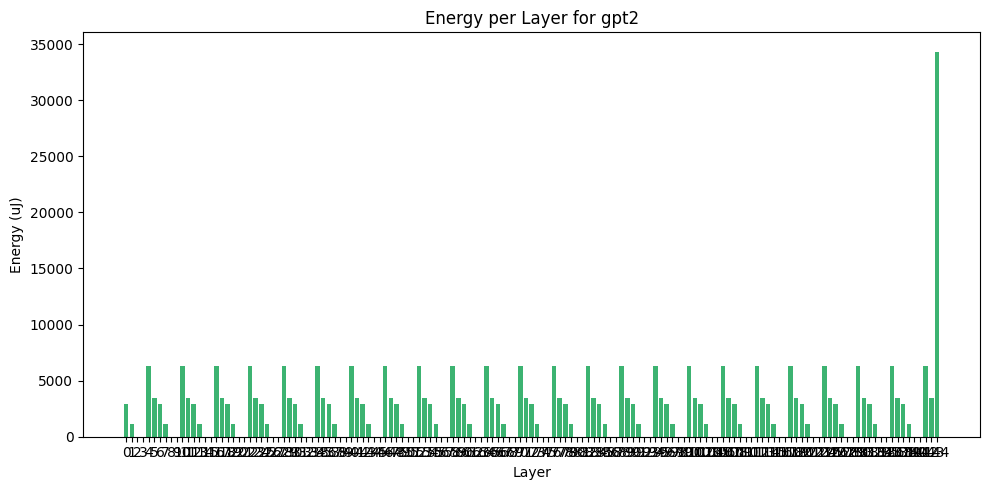

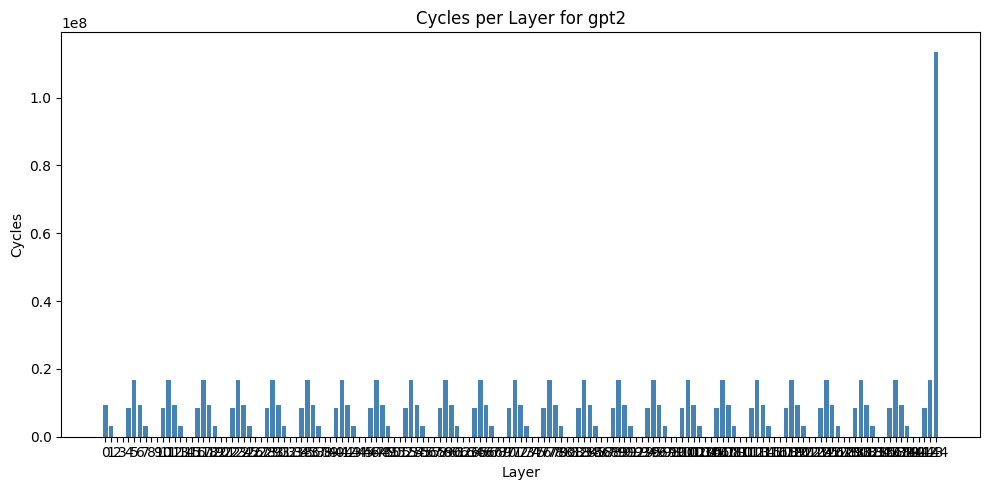

In [4]:
layer_data = extract_outputs("gpt2", "gpt2_128")
plot_energy_and_cycles_per_layer(layer_data)

In [5]:
all_layers_percent

{'000': {'mac': 18.158733795368196,
  'output_activation_reg': 2.890854491748014,
  'input_activation_reg': 2.9134925635297937,
  'weight_reg': 2.9134925635297937,
  'pe_spad': 0.13255545645716904,
  'shared_glb': 15.031952410954647,
  'DRAM': 57.95891871841239},
 '001': {'mac': 16.28400705394901,
  'output_activation_reg': 2.571854156424499,
  'input_activation_reg': 2.612700532470423,
  'weight_reg': 2.612700532470423,
  'pe_spad': 0.29888785346179153,
  'shared_glb': 11.415216864906116,
  'DRAM': 64.20463300631774},
 '002': {'mac': 5.623660646032134,
  'output_activation_reg': 0.676677312515785,
  'input_activation_reg': 0.9022927290342798,
  'weight_reg': 0.9022927290342798,
  'pe_spad': 1.6318473349759646,
  'shared_glb': 1.5712834062437442,
  'DRAM': 88.69194584216382},
 '003': {'mac': 5.503932620495922,
  'output_activation_reg': 0.8762212452443978,
  'input_activation_reg': 0.8830828702425377,
  'weight_reg': 0.8830828702425377,
  'pe_spad': 1.597105220952592,
  'shared_glb': 3

In [6]:
layer_data

[{'Layer': 0, 'Energy (uJ)': 2952.56, 'Cycles': 9388032.0},
 {'Layer': 1, 'Energy (uJ)': 1097.49, 'Cycles': 3129344.0},
 {'Layer': 2, 'Energy (uJ)': 3.1, 'Cycles': 2048.0},
 {'Layer': 3, 'Energy (uJ)': 12.68, 'Cycles': 8192.0},
 {'Layer': 4, 'Energy (uJ)': 6282.05, 'Cycles': 8388608.0},
 {'Layer': 5, 'Energy (uJ)': 3455.87, 'Cycles': 16760832.0},
 {'Layer': 6, 'Energy (uJ)': 2952.56, 'Cycles': 9388032.0},
 {'Layer': 7, 'Energy (uJ)': 1097.49, 'Cycles': 3129344.0},
 {'Layer': 8, 'Energy (uJ)': 3.1, 'Cycles': 2048.0},
 {'Layer': 9, 'Energy (uJ)': 12.68, 'Cycles': 8192.0},
 {'Layer': 10, 'Energy (uJ)': 6282.05, 'Cycles': 8388608.0},
 {'Layer': 11, 'Energy (uJ)': 3455.87, 'Cycles': 16760832.0},
 {'Layer': 12, 'Energy (uJ)': 2952.56, 'Cycles': 9388032.0},
 {'Layer': 13, 'Energy (uJ)': 1097.49, 'Cycles': 3129344.0},
 {'Layer': 14, 'Energy (uJ)': 3.1, 'Cycles': 2048.0},
 {'Layer': 15, 'Energy (uJ)': 12.68, 'Cycles': 8192.0},
 {'Layer': 16, 'Energy (uJ)': 6282.05, 'Cycles': 8388608.0},
 {'Laye

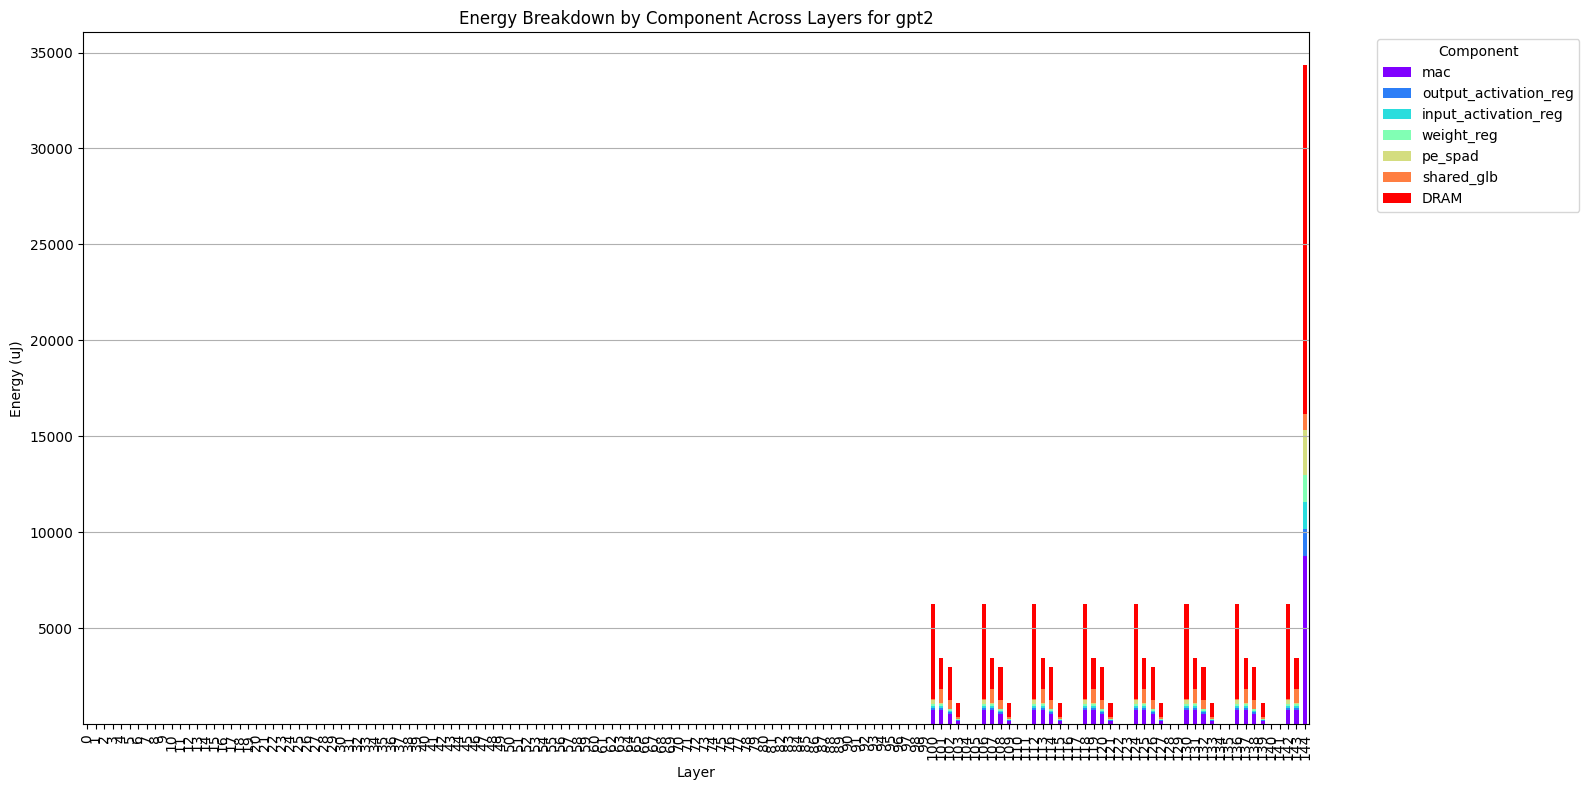

In [7]:
component_energy_by_layer = []
for entry in layer_data:
    layer_index = entry['Layer']
    layer_key = f"{layer_index:02d}"
    total_energy = entry['Energy (uJ)']
    percent_dict = all_layers_percent.get(layer_key, {})
    
    component_energies = {'Layer': layer_index}
    for component, percent in percent_dict.items():
        component_energies[component] = (percent / 100.0) * total_energy
    
    component_energy_by_layer.append(component_energies)

# Convert to DataFrame
df = pd.DataFrame(component_energy_by_layer)
df.set_index('Layer', inplace=True)
df.fillna(0, inplace=True)

# Plot stacked bar chart
from matplotlib import colormaps
import numpy as np
colors = plt.get_cmap('rainbow')(np.linspace(0, 1, df.shape[1]))# You can also use 'Set3', 'nipy_spectral', 'rainbow'
ax = df.plot(kind='bar', stacked=True, figsize=(16, 8), color=colors)

plt.ylabel('Energy (uJ)')
plt.title('Energy Breakdown by Component Across Layers for gpt2')
plt.legend(title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y')
plt.show()